# EDA 01 — Rainfall, Seasonality, Correlation, and West Bengal Maps

This notebook uses the cleaned outputs from `EDA_00_data_validation.ipynb` and follows the flow: station coverage, monthly seasonality, rolling rainfall, district correlation, and district-wise West Bengal maps. The emphasis is on simple, interpretable plots that can be reused for other areas/ data.

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from scipy.stats import linregress
from pathlib import Path

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

sns.set_theme(style="whitegrid")

# -------------------------------------------------------------------
# Paths: update to local folder names differ
# -------------------------------------------------------------------
BASE_DIR = Path(r"C:/Users/rishe/Dissertation/data")
PROCESSED_DIR = BASE_DIR / "processed"
DATA_DIR = BASE_DIR / "gee_era5_data"
SHAPEFILE = BASE_DIR / "West_Bengal" / "District_shape_West_Bengal.shp"
OUTPUT_DIR = BASE_DIR / "eda_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------------------------------------------------
# Load processed outputs from Notebook 00
# -------------------------------------------------------------------
station_level = pd.read_parquet(PROCESSED_DIR / "era5_station_level_clean.parquet")
district_daily = pd.read_parquet(PROCESSED_DIR / "era5_district_daily_mean.parquet")
monthly_district = pd.read_parquet(PROCESSED_DIR / "era5_monthly_district.parquet")
district_map = pd.read_csv(PROCESSED_DIR / "district_mapping.csv")


## 1) Basic sanity check and district station counts

We begin with the number of stations in each district because it gives immediate context for coverage and spatial balance.

In [2]:

# Standardize names for easy merging/plotting
def normalize_name(x):
    return str(x).strip()
canonical_map = {
    "DARJEELING": "Darjeeling",
    "Darjiling": "Darjeeling",

    "HOOGHLY": "Hooghly",
    "HOOGLY": "Hooghly",  # Added for data spelling
    "Hugli": "Hooghly",

    "HOWRAH": "Howrah",
    "Haora": "Howrah",

    "COOCH BEHAR": "Cooch Behar",
    "Koch Bihar": "Cooch Behar",

    "PURULIA": "Purulia",
    "Puruliya": "Purulia",

    "MALDA": "Maldah",
    "Maldah": "Maldah",

    "24 PARGANAS N": "North 24 Parganas",
    "North 24 Parganas": "North 24 Parganas",

    "24 PARGANAS S": "South 24 Parganas",
    "South 24 Parganas": "South 24 Parganas",

    "PASCHIM MEDINIPUR": "Paschim Medinipur",
    "Paschim Medinipur": "Paschim Medinipur",
    "Pashchim Medinipur": "Paschim Medinipur",  # Added for shapefile spelling

    "PURBA MEDINIPUR": "Purba Medinipur",
    "Purba Medinipur": "Purba Medinipur",

    "PASCHIM BARDHAMAN": "Paschim Bardhaman",
    "Paschim Barddhaman": "Paschim Bardhaman",

    "PURBA BARDHAMAN": "Purba Bardhaman",
    "Purba Barddhaman": "Purba Bardhaman",

    "JALPAIGURI": "Jalpaiguri",
    "Jalpaiguri": "Jalpaiguri",

    "BANKURA": "Bankura",
    "Bankura": "Bankura",

    "BIRBHUM": "Birbhum",
    "Birbhum": "Birbhum",

    "NADIA": "Nadia",
    "Nadia": "Nadia",

    "MURSHIDABAD": "Murshidabad",
    "Murshidabad": "Murshidabad",

    "KOLKATA": "Kolkata",
    "Kolkata": "Kolkata",

    "ALIPURDUAR": "Alipurduar",
    "Alipurduar": "Alipurduar",

    "KALIMPONG": "Kalimpong",
    "Kalimpong": "Kalimpong",

    "JHARGRAM": "Jhargram",
    "Jhargram": "Jhargram",

    "DINAJPUR SOUTH": "Dakshin Dinajpur",
    "DAKSHIN DINAJPUR": "Dakshin Dinajpur",  # Added for data spelling
    "Dakshin Dinajpur": "Dakshin Dinajpur",

    "DINAJPUR NORTH": "Uttar Dinajpur",
    "UTTAR DINAJPUR": "Uttar Dinajpur",  # Added for data spelling
    "Uttar Dinajpur": "Uttar Dinajpur",
}

district_map["district_std"] = district_map["district"].map(normalize_name).map(canonical_map).fillna(district_map["district"])
district_map["district_std"] = district_map["district_std"].astype(str)

station_counts = (
    district_map.groupby("district_std", as_index=False)
    .agg(stations=("station_id", "nunique"))
    .sort_values("stations", ascending=False)
)

station_counts


,district_std,stations
1,Bankura,31
19,Purba Medinipur,21
5,Darjeeling,19
20,Purulia,19
17,Paschim Medinipur,19
13,Murshidabad,18
2,Birbhum,16
0,Alipurduar,15
6,Hooghly,14
8,Jalpaiguri,14


In [15]:
monthly_district["district"] = monthly_district["district"].map(normalize_name).map(canonical_map).fillna(monthly_district["district"])

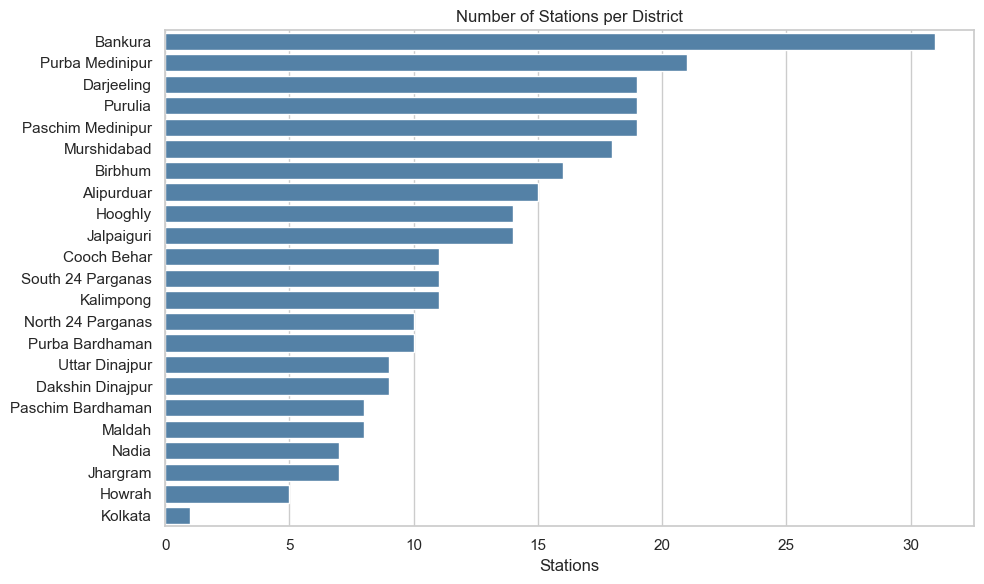

In [16]:

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=station_counts, x="stations", y="district_std", ax=ax, color="steelblue")
ax.set_title("Number of Stations per District")
ax.set_xlabel("Stations")
ax.set_ylabel("")
plt.tight_layout()

fig.savefig(OUTPUT_DIR / "01_station_counts_by_district.png", dpi=300, bbox_inches="tight")
plt.show()


## 2) Monthly climatology and seasonality

The June–September is monsoon peak. We wanted to see the clear distinction between the non-monsoon months and the monsoon months.

C:\Users\rishe\AppData\Local\Temp\ipykernel_17232\2124909922.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])


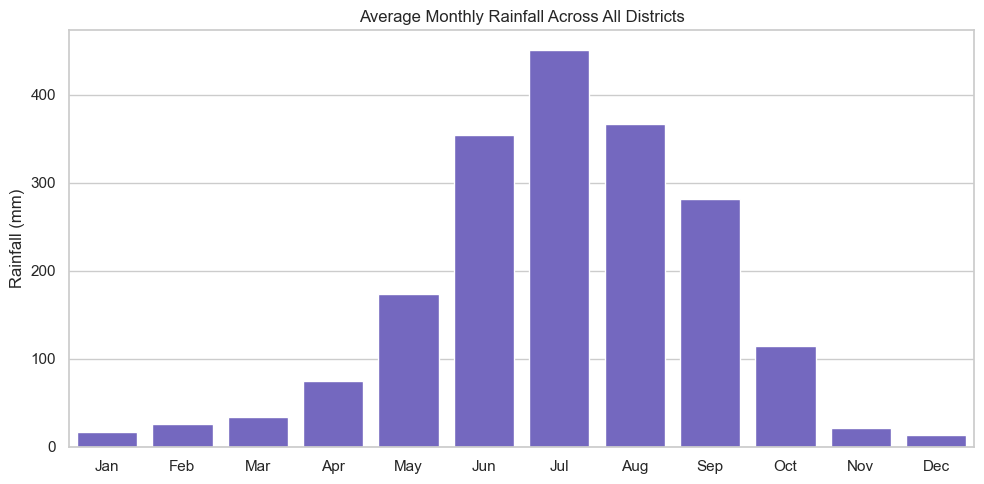

In [17]:

monthly_district["month_name"] = pd.to_datetime(monthly_district["date_month"]).dt.strftime("%b")
monthly_district["season"] = pd.cut(
    monthly_district["month"],
    bins=[0, 2, 5, 9, 12],
    labels=["Winter", "Pre-monsoon", "Monsoon", "Post-monsoon"],
    include_lowest=True
)

# Average monthly rainfall across the full period
monthly_clim = (
    monthly_district.groupby("month", as_index=False)
    .agg(avg_precip_mm=("precip_mm", "mean"))
    .sort_values("month")
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=monthly_clim, x="month", y="avg_precip_mm", ax=ax, color="slateblue")
ax.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
ax.set_title("Average Monthly Rainfall Across All Districts")
ax.set_xlabel("")
ax.set_ylabel("Rainfall (mm)")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "02_average_monthly_rainfall.png", dpi=300, bbox_inches="tight")
plt.show()


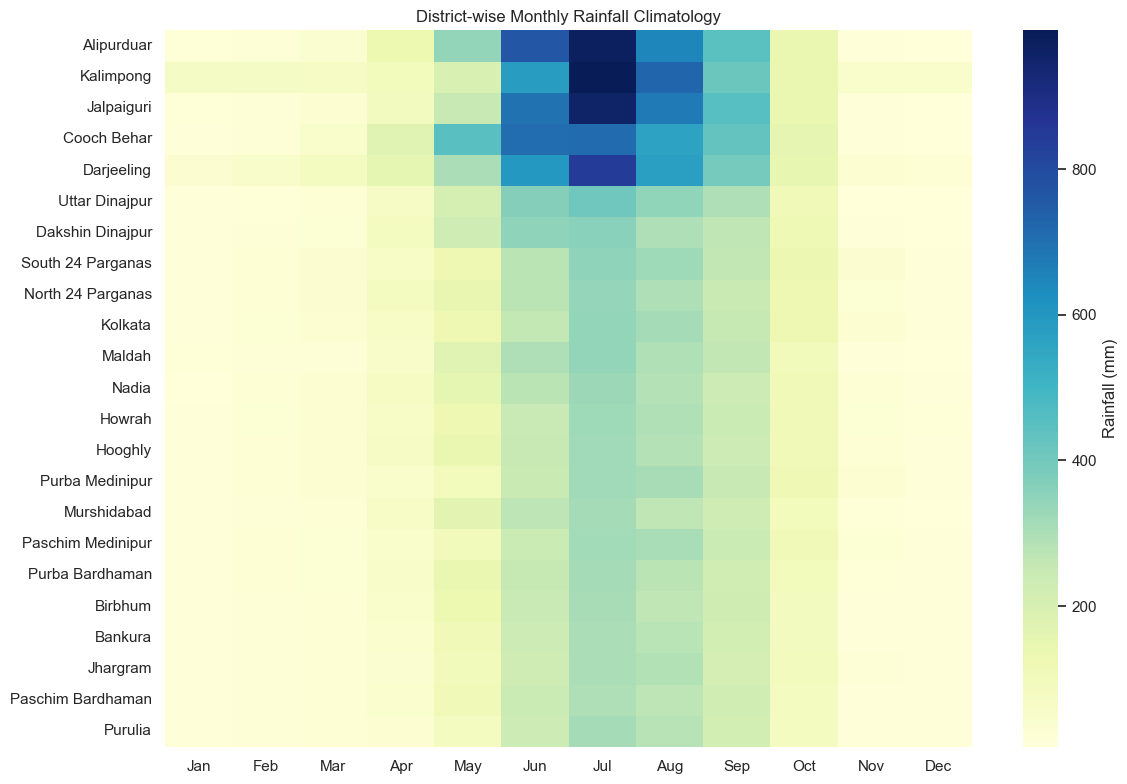

In [18]:

# District x month heatmap: compact way to show the full seasonal cycle
district_month_clim = (
    monthly_district.groupby(["district", "month"], as_index=False)
    .agg(avg_precip_mm=("precip_mm", "mean"))
)

district_order = (
    district_month_clim.groupby("district")["avg_precip_mm"].mean()
    .sort_values(ascending=False)
    .index.tolist()
)

heatmap_df = (
    district_month_clim.pivot(index="district", columns="month", values="avg_precip_mm")
    .reindex(district_order)
)

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    heatmap_df,
    cmap="YlGnBu",
    ax=ax,
    cbar_kws={"label": "Rainfall (mm)"}
)
ax.set_title("District-wise Monthly Rainfall Climatology")
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "03_district_month_climatology_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


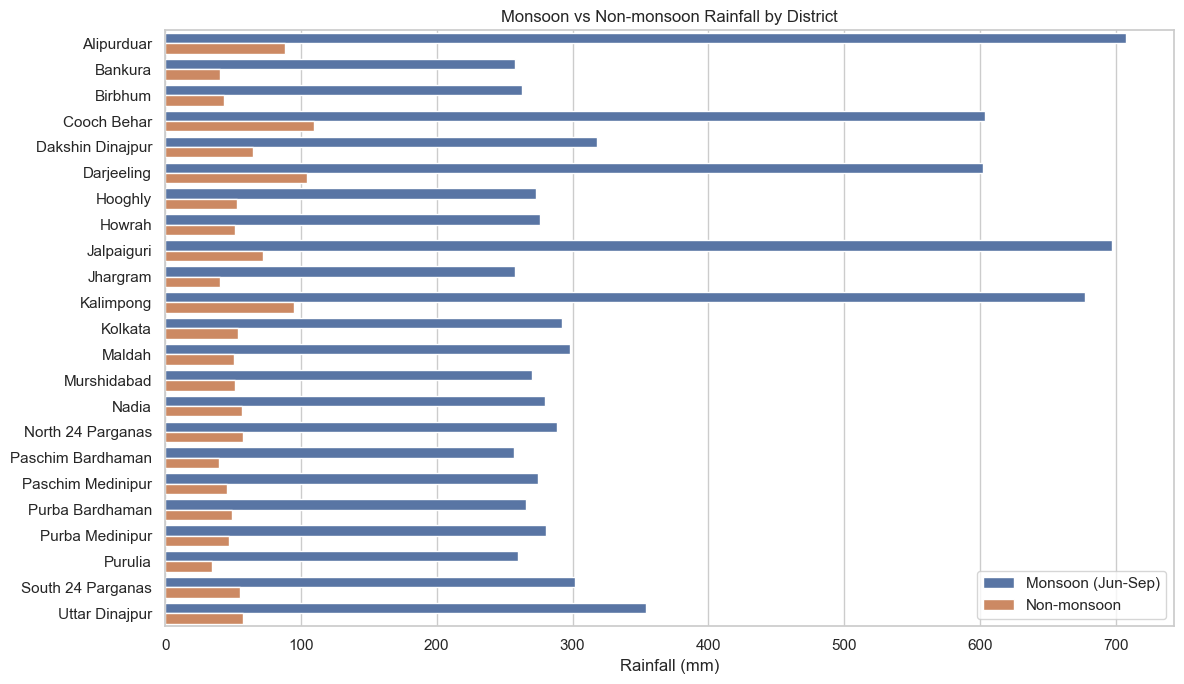

In [19]:

# Monsoon vs non-monsoon comparison by district
monthly_district["is_monsoon"] = monthly_district["month"].between(6, 9)

seasonal_share = (
    monthly_district.assign(period=np.where(monthly_district["is_monsoon"], "Monsoon (Jun-Sep)", "Non-monsoon"))
    .groupby(["district", "period"], as_index=False)
    .agg(avg_precip_mm=("precip_mm", "mean"))
)

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(
    data=seasonal_share,
    y="district",
    x="avg_precip_mm",
    hue="period",
    ax=ax
)
ax.set_title("Monsoon vs Non-monsoon Rainfall by District")
ax.set_xlabel("Rainfall (mm)")
ax.set_ylabel("")
plt.legend(title="")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "04_monsoon_vs_nonmonsoon_by_district.png", dpi=300, bbox_inches="tight")
plt.show()


## 3) Annual rainfall and rolling average

This is long-term moving-average plot, but across ERA5 time span [1970 - 2023]. We keep the plot readable by using annual totals and a 10-year rolling mean.

In [41]:
district_annual = (
    monthly_district.groupby(["district", "year"], as_index=False)
    .agg(annual_precip_mm=("precip_mm", "sum"))
)

district_annual = district_annual.sort_values(["district", "year"])
district_annual["rolling10"] = (
    district_annual.groupby("district")["annual_precip_mm"]
    .transform(lambda s: s.rolling(window=10, min_periods=5).mean())
)

annual_order = (
    district_annual.groupby("district")["annual_precip_mm"].mean()
    .sort_values(ascending=False)
    .index.tolist()
)

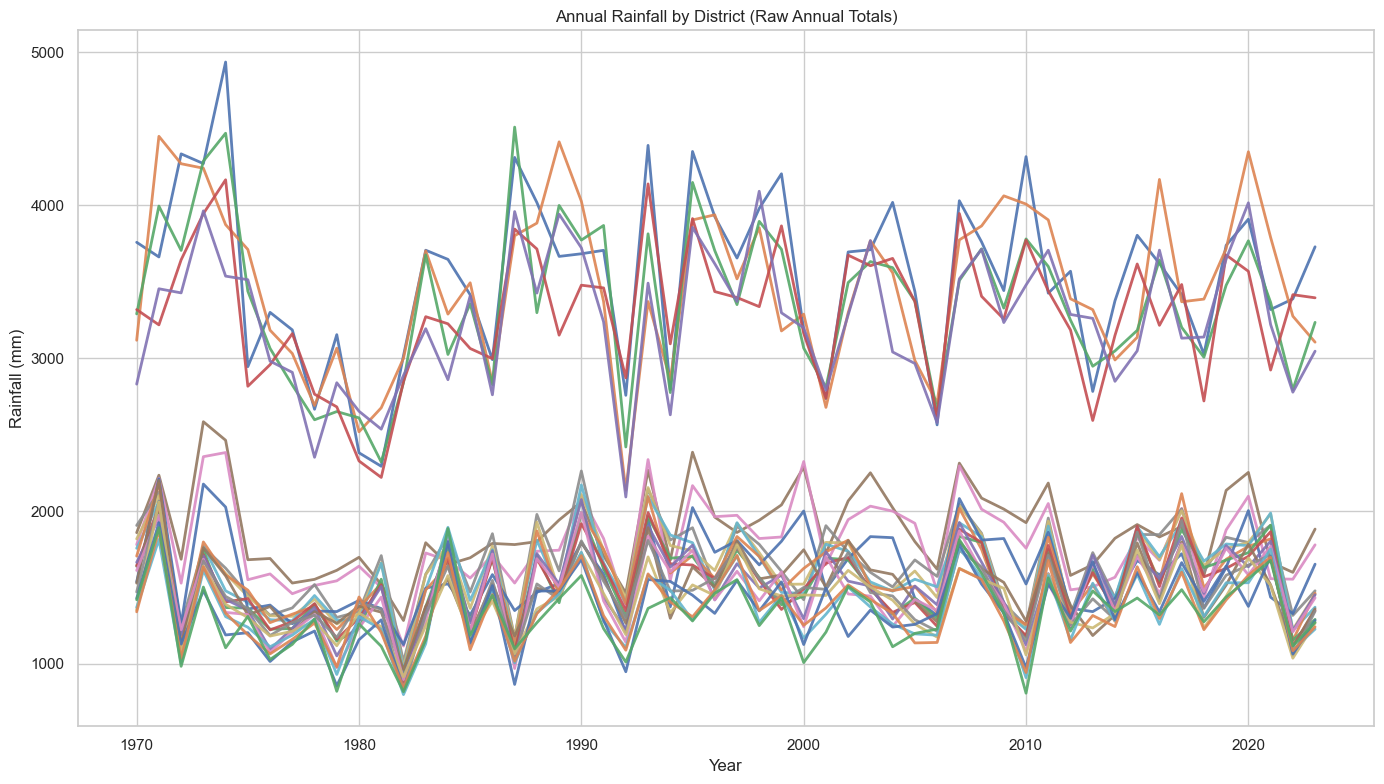

In [40]:

#  annual totals 
fig, ax = plt.subplots(figsize=(14, 8))
for d in annual_order:
    sub = district_annual[district_annual["district"] == d]
    ax.plot(sub["year"], sub["annual_precip_mm"], linewidth=2, alpha=0.9)

ax.set_title("Annual Rainfall by District (Raw Annual Totals)")
ax.set_xlabel("Year")
ax.set_ylabel("Rainfall (mm)")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "06_annual_rainfall_by_district_raw.png", dpi=300, bbox_inches="tight")
plt.show()


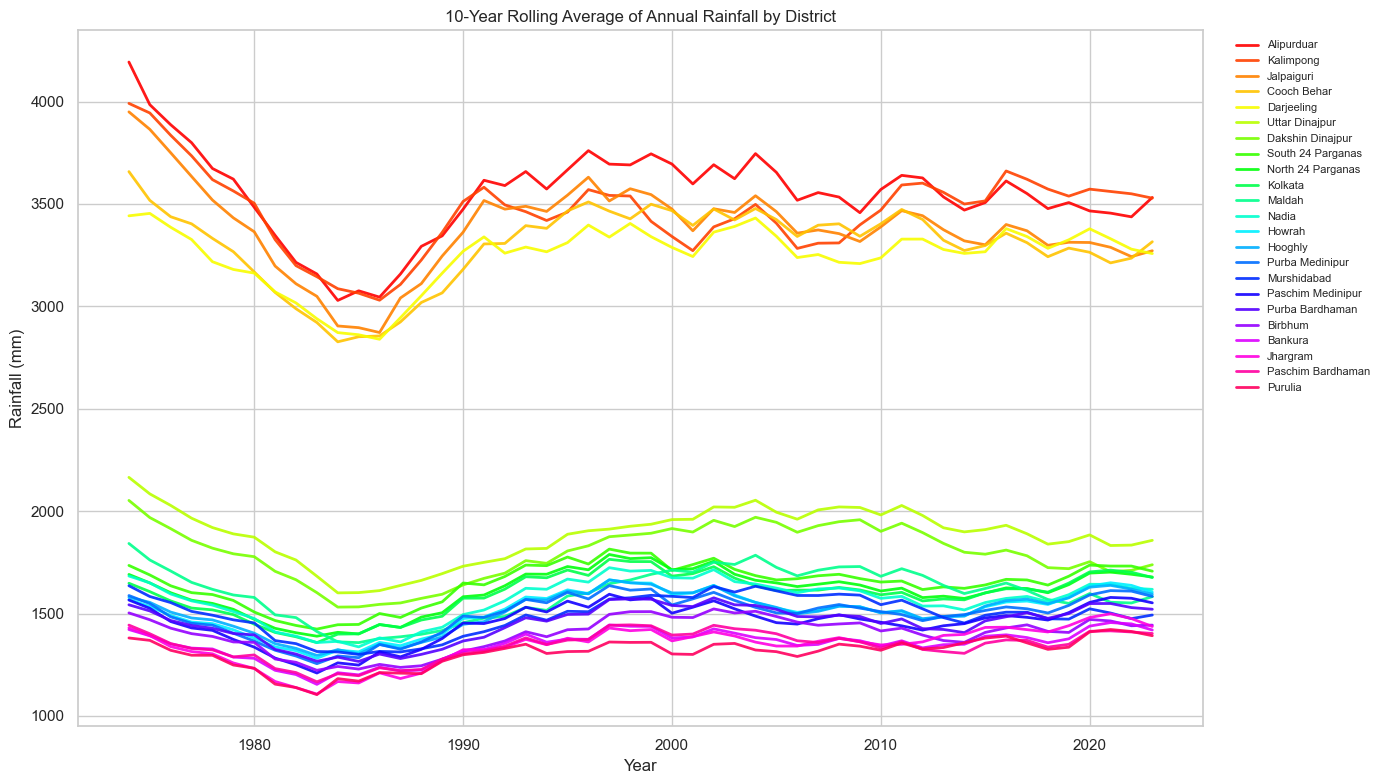

In [ ]:



# fig, ax = plt.subplots(figsize=(14, 8))
# for d in annual_order:
#     sub = district_annual[district_annual["district"] == d]
#     ax.plot(sub["year"], sub["rolling10"], linewidth=2, alpha=0.9, label=d)

# ax.set_title("10-Year Rolling Average of Annual Rainfall by District")
# ax.set_xlabel("Year")
# ax.set_ylabel("Rainfall (mm)")
# ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, frameon=False)
# plt.tight_layout()
# fig.savefig(OUTPUT_DIR / "05_rolling10_annual_rainfall_by_district.png", dpi=300, bbox_inches="tight")
# plt.show()
import matplotlib.cm as cm
import numpy as np

n_districts = len(annual_order)
colors = cm.hsv(np.linspace(0, 0.95, n_districts))  # hsv has many distinct colors

fig, ax = plt.subplots(figsize=(14, 8))
for i, d in enumerate(annual_order):
    sub = district_annual[district_annual["district"] == d]
    ax.plot(sub["year"], sub["rolling10"], linewidth=2, alpha=0.9, label=d, color=colors[i])

ax.set_title("10-Year Rolling Average of Annual Rainfall by District")
ax.set_xlabel("Year")
ax.set_ylabel("Rainfall (mm)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, frameon=False)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "05_rolling10_annual_rainfall_by_district.png", dpi=300, bbox_inches="tight")
plt.show()


## 4) District correlation matrix

we use monthly rainfall series and show which districts move together.

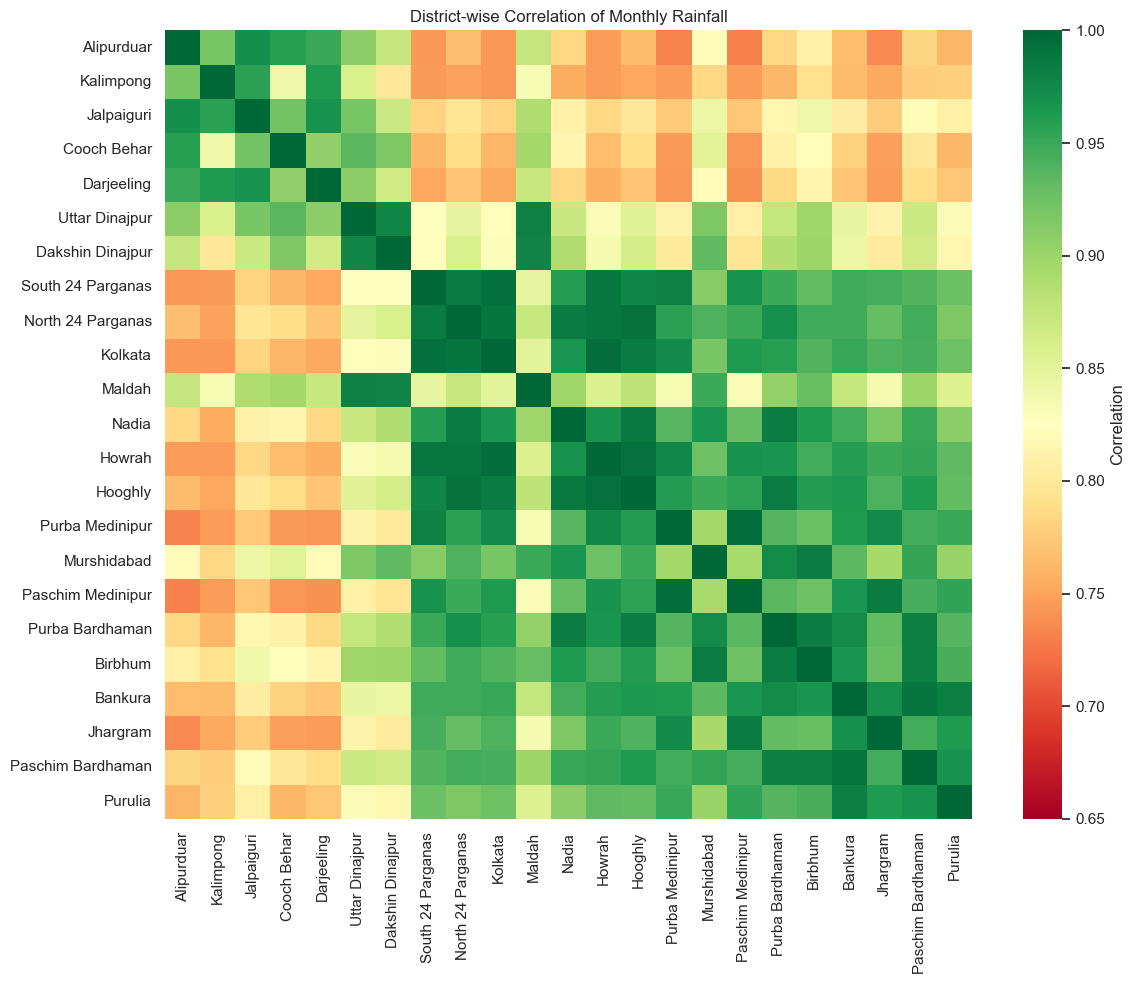

In [43]:

monthly_pivot = monthly_district.pivot_table(
    index="date_month",
    columns="district",
    values="precip_mm",
    aggfunc="mean"
).sort_index()

corr_monthly = monthly_pivot.corr()

# Order by long-term mean rainfall for readability
corr_order = (
    monthly_district.groupby("district")["precip_mm"].mean()
    .sort_values(ascending=False)
    .index.tolist()
)
fig, ax = plt.subplots(figsize=(12, 10))

# Plotting the heatmap with the corrected color scale
sns.heatmap(
    corr_monthly.loc[corr_order, corr_order],
    cmap="RdYlGn",          # Red for low, Yellow for mid, Green for high
    vmin=0.65,               # Anchor the bottom of the color scale
    vmax=1.0,               # Anchor the top of the color scale
    ax=ax,
    cbar_kws={"label": "Correlation"},
    annot=False             # Set to True if you want the actual numbers printed in the boxes
)

ax.set_title("District-wise Correlation of Monthly Rainfall")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()

# Save and show
fig.savefig(OUTPUT_DIR / "07_district_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


## 5) West Bengal choropleth maps

The map section is the main visual part of the dissertation. We keep the plots simple, district-wise, and easy to compare across periods.

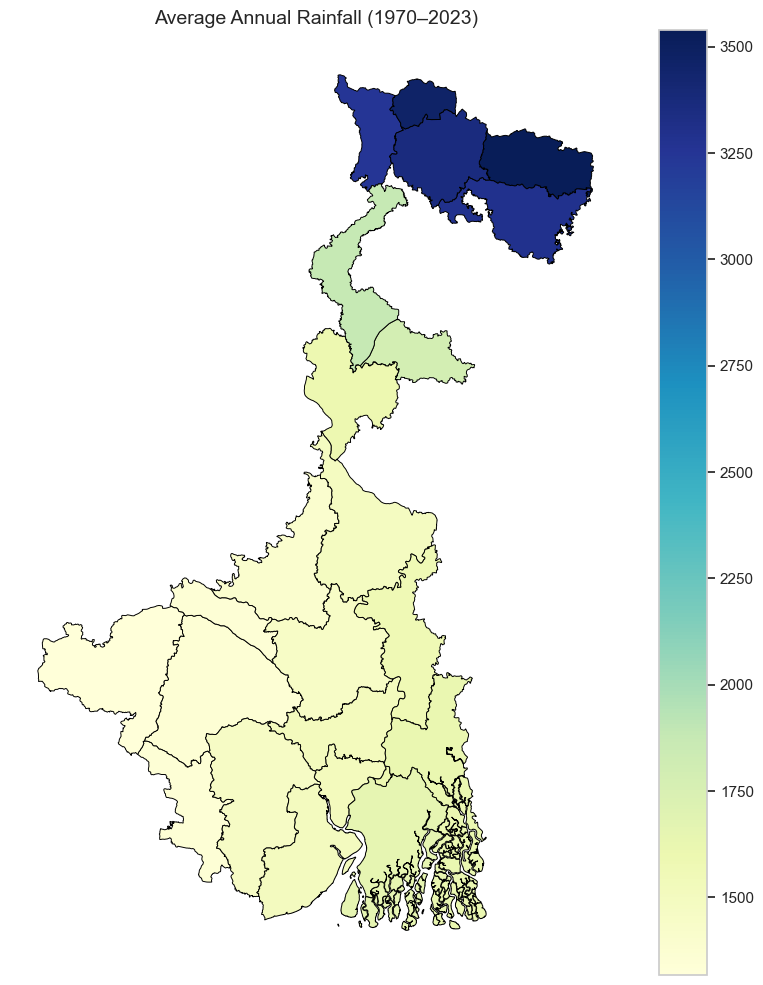

In [23]:

gdf = gpd.read_file(SHAPEFILE)

# Standardize shapefile district names
if "NAME" in gdf.columns:
    name_col = "NAME"
elif "district" in gdf.columns:
    name_col = "district"
else:
    name_col = gdf.columns[0]  # fallback if needed

gdf["district_std"] = gdf[name_col].map(normalize_name).map(canonical_map).fillna(gdf[name_col])
gdf["district_std"] = gdf["district_std"].astype(str)

# Dissolve duplicate geometries if the shapefile has multiple rows for the same district
gdf = gdf.dissolve(by="district_std", as_index=False)

def plot_map(data_gdf, value_col, title, cmap="YlGnBu", legend_label=None, figsize=(8, 10), edgecolor="black"):
    fig, ax = plt.subplots(figsize=figsize)
    data_gdf.plot(
        column=value_col,
        cmap=cmap,
        linewidth=0.7,
        edgecolor=edgecolor,
        legend=True,
        ax=ax,
        missing_kwds={"color": "lightgrey", "label": "Missing"}
    )
    ax.set_title(title, fontsize=14)
    ax.axis("off")
    plt.tight_layout()
    return fig, ax

# Full-period average annual rainfall map
avg_annual = (
    district_annual.groupby("district", as_index=False)
    .agg(avg_annual_precip_mm=("annual_precip_mm", "mean"))
    .rename(columns={"district": "district_std"})
)

map_avg = gdf.merge(avg_annual, on="district_std", how="left")
fig, ax = plot_map(map_avg, "avg_annual_precip_mm", "Average Annual Rainfall (1970–2023)")
fig.savefig(OUTPUT_DIR / "08_map_average_annual_rainfall.png", dpi=300, bbox_inches="tight")
plt.show()


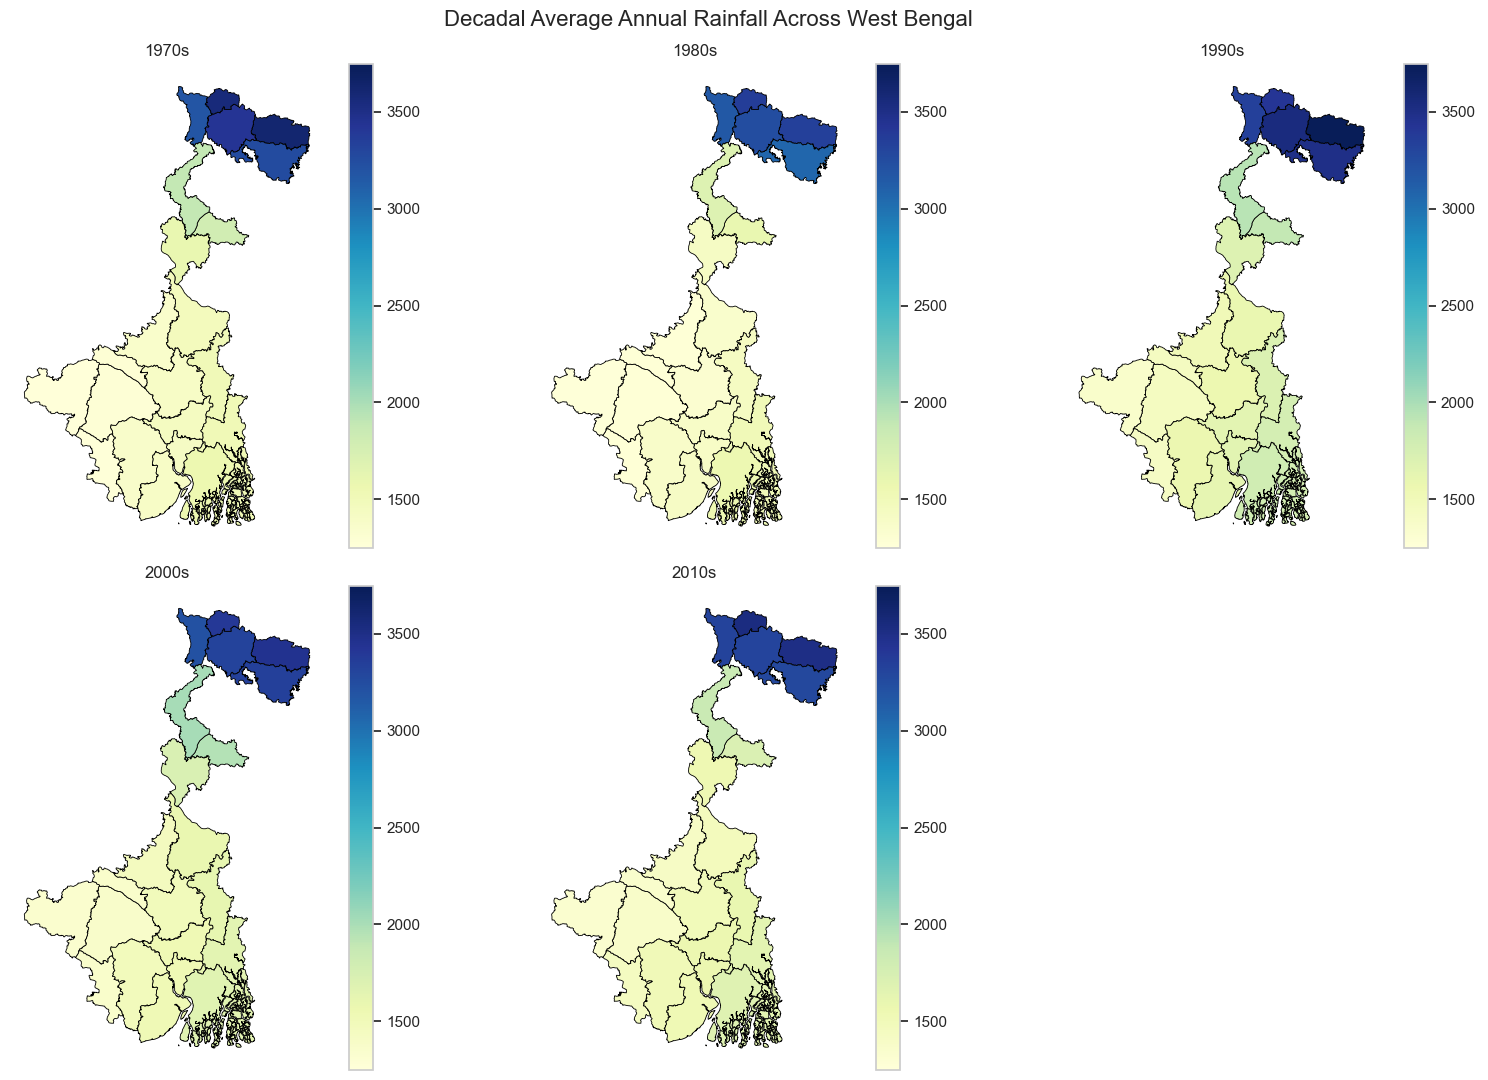

In [42]:
# Decadal maps: 1970s, 1980s, 1990s, 2000s, 2010s
decades = {
    "1970s": (1970, 1979),
    "1980s": (1980, 1989),
    "1990s": (1990, 1999),
    "2000s": (2000, 2009),
    "2010s": (2010, 2019),
}

decadal_frames = []
for label, (y0, y1) in decades.items():
    tmp = (
        district_annual[(district_annual["year"] >= y0) & (district_annual["year"] <= y1)]
        .groupby("district", as_index=False)
        .agg(mean_annual_precip_mm=("annual_precip_mm", "mean"))
    )
    tmp["decade"] = label
    decadal_frames.append(tmp)

decadal_avg = pd.concat(decadal_frames, ignore_index=True)

# Calculate global min and max for consistent color scale
vmin = decadal_avg["mean_annual_precip_mm"].min()
vmax = decadal_avg["mean_annual_precip_mm"].max()

fig, axes = plt.subplots(2, 3, figsize=(16, 11))
axes = axes.flatten()

for i, (label, _) in enumerate(decades.items()):
    ax = axes[i]
    sub = decadal_avg[decadal_avg["decade"] == label].rename(columns={"district": "district_std"})
    plot_gdf = gdf.merge(sub[["district_std", "mean_annual_precip_mm"]], on="district_std", how="left")
    plot_gdf.plot(
        column="mean_annual_precip_mm",
        cmap="YlGnBu",
        linewidth=0.6,
        edgecolor="black",
        legend=True,
        ax=ax,
        vmin=vmin,  # Set consistent minimum
        vmax=vmax,  # Set consistent maximum
        missing_kwds={"color": "lightgrey"}
    )
    ax.set_title(label)
    ax.axis("off")

axes[-1].axis("off")
fig.suptitle("Decadal Average Annual Rainfall Across West Bengal", fontsize=16)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "09_decadal_average_annual_rainfall_maps.png", dpi=300, bbox_inches="tight")
plt.show()

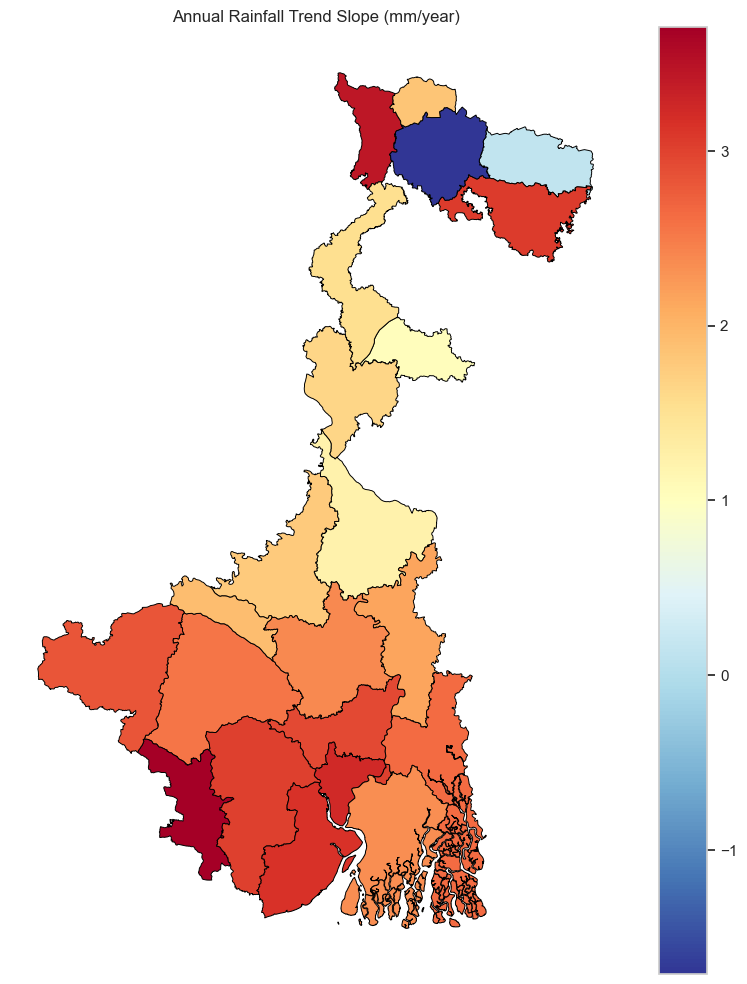

,district_std,slope_mm_per_year,p_value,r_value
8,Jalpaiguri,-1.711266,0.704043,-0.052895
0,Alipurduar,0.143197,0.976947,0.004027
4,Dakshin Dinajpur,1.037460,0.683239,0.056813
13,Murshidabad,1.217303,0.561132,0.080848
22,Uttar Dinajpur,1.539734,0.531324,0.087061
12,Maldah,1.650648,0.484131,0.097263
2,Birbhum,1.761239,0.371031,0.124165
10,Kalimpong,1.843253,0.693540,0.054868
16,Paschim Bardhaman,1.922666,0.345084,0.130995
14,Nadia,2.151018,0.368459,0.124829


In [ ]:

# Trend slope map: annual rainfall slope per district across the full available period
trend_rows = []
for d, sub in district_annual.groupby("district"):
    x = sub["year"].values
    y = sub["annual_precip_mm"].values
    if len(np.unique(x)) > 1:
        slope, intercept, r, p, se = linregress(x, y)
        trend_rows.append({
            "district": d,+
            "slope_mm_per_year": slope,
            "p_value": p,
            "r_value": r
        })

trend_df = pd.DataFrame(trend_rows).rename(columns={"district": "district_std"})
map_trend = gdf.merge(trend_df, on="district_std", how="left")

fig, ax = plt.subplots(figsize=(8, 10))
map_trend.plot(
    column="slope_mm_per_year",
    cmap="RdYlBu_r",
    linewidth=0.7,
    edgecolor="black",
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey", "label": "Missing"}
)
ax.set_title("Annual Rainfall Trend Slope (mm/year)")
ax.axis("off")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "10_trend_slope_map.png", dpi=300, bbox_inches="tight")
plt.show()

trend_df.sort_values("slope_mm_per_year")


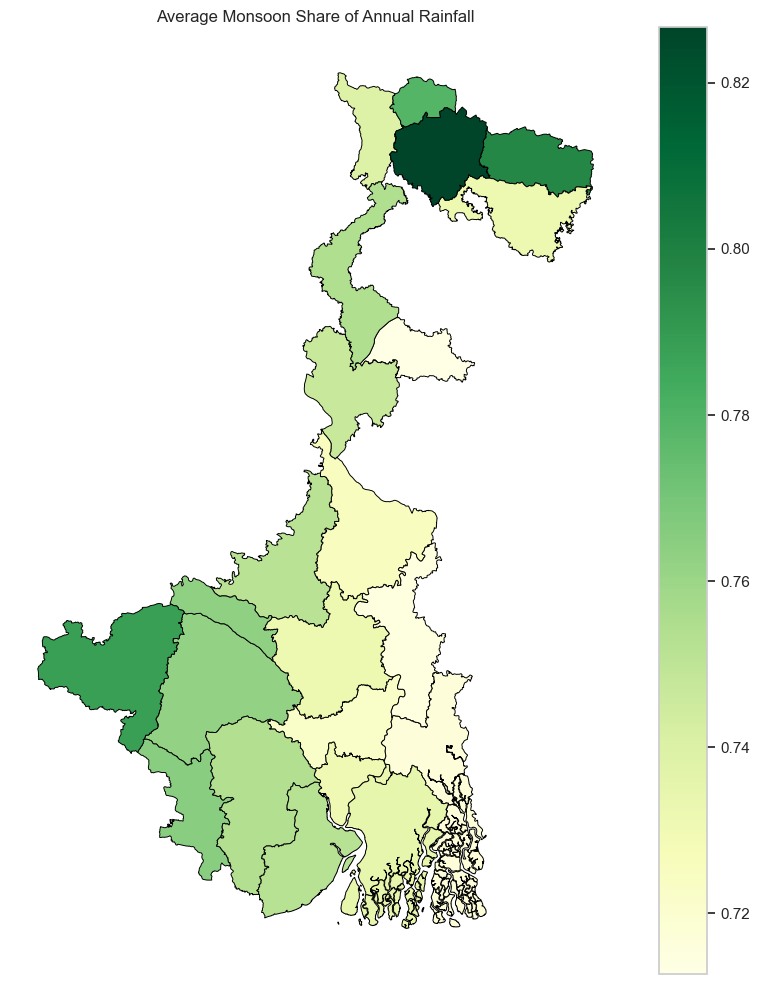

,district_std,avg_monsoon_share
8,Jalpaiguri,0.826664
0,Alipurduar,0.797089
20,Purulia,0.788261
10,Kalimpong,0.778861
9,Jhargram,0.765142
16,Paschim Bardhaman,0.763379
1,Bankura,0.762472
22,Uttar Dinajpur,0.754248
17,Paschim Medinipur,0.753905
19,Purba Medinipur,0.752125


In [26]:

# Monsoon share map: June-Sep rainfall / annual rainfall
district_monthly = monthly_district.copy()
district_monthly["is_monsoon"] = district_monthly["month"].between(6, 9)

monsoon_by_year = (
    district_monthly[district_monthly["is_monsoon"]]
    .groupby(["district", "year"], as_index=False)
    .agg(monsoon_precip_mm=("precip_mm", "sum"))
)

annual_by_year = (
    district_monthly.groupby(["district", "year"], as_index=False)
    .agg(annual_precip_mm=("precip_mm", "sum"))
)

monsoon_share = annual_by_year.merge(monsoon_by_year, on=["district", "year"], how="left").fillna({"monsoon_precip_mm": 0})
monsoon_share["monsoon_share"] = np.where(
    monsoon_share["annual_precip_mm"] > 0,
    monsoon_share["monsoon_precip_mm"] / monsoon_share["annual_precip_mm"],
    np.nan
)

monsoon_share_summary = (
    monsoon_share.groupby("district", as_index=False)
    .agg(avg_monsoon_share=("monsoon_share", "mean"))
    .rename(columns={"district": "district_std"})
)

map_monsoon = gdf.merge(monsoon_share_summary, on="district_std", how="left")
fig, ax = plt.subplots(figsize=(8, 10))
map_monsoon.plot(
    column="avg_monsoon_share",
    cmap="YlGn",
    linewidth=0.7,
    edgecolor="black",
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey", "label": "Missing"}
)
ax.set_title("Average Monsoon Share of Annual Rainfall")
ax.axis("off")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "11_map_monsoon_share.png", dpi=300, bbox_inches="tight")
plt.show()

monsoon_share_summary.sort_values("avg_monsoon_share", ascending=False)


## 6) Extreme wet and dry years

A simple way to capture instability is to count unusually wet and unusually dry years from standardized annual rainfall. 

In [ ]:

# Baseline for standardization: first 30 years keeps the metric anchored to an early climatology
baseline_years = (1970, 1999)

baseline_annual = district_annual[
    (district_annual["year"] >= baseline_years[0]) &
    (district_annual["year"] <= baseline_years[1])
].copy()

baseline_stats = (
    baseline_annual.groupby("district", as_index=False)
    .agg(mu=("annual_precip_mm", "mean"), sigma=("annual_precip_mm", "std"))
)

extreme = district_annual.merge(baseline_stats, on="district", how="left")
extreme["z"] = (extreme["annual_precip_mm"] - extreme["mu"]) / extreme["sigma"]

extreme["wet"] = extreme["z"] >= 1.0 # find justification for this threshold in the literature - it's a common choice for defining "extreme" events in climatology, representing years that are more than 1 standard deviation above the baseline mean, which captures significant positive anomalies without being too restrictive. This threshold allows us to identify years with notably higher rainfall while still having enough events to analyze patterns and trends across districts.
extreme["dry"] = extreme["z"] <= -1.0

extreme_counts = (
    extreme.groupby("district", as_index=False)
    .agg(
        wet_years=("wet", "sum"),
        dry_years=("dry", "sum")
    )
    .rename(columns={"district": "district_std"})
)

map_extreme = gdf.merge(extreme_counts, on="district_std", how="left")


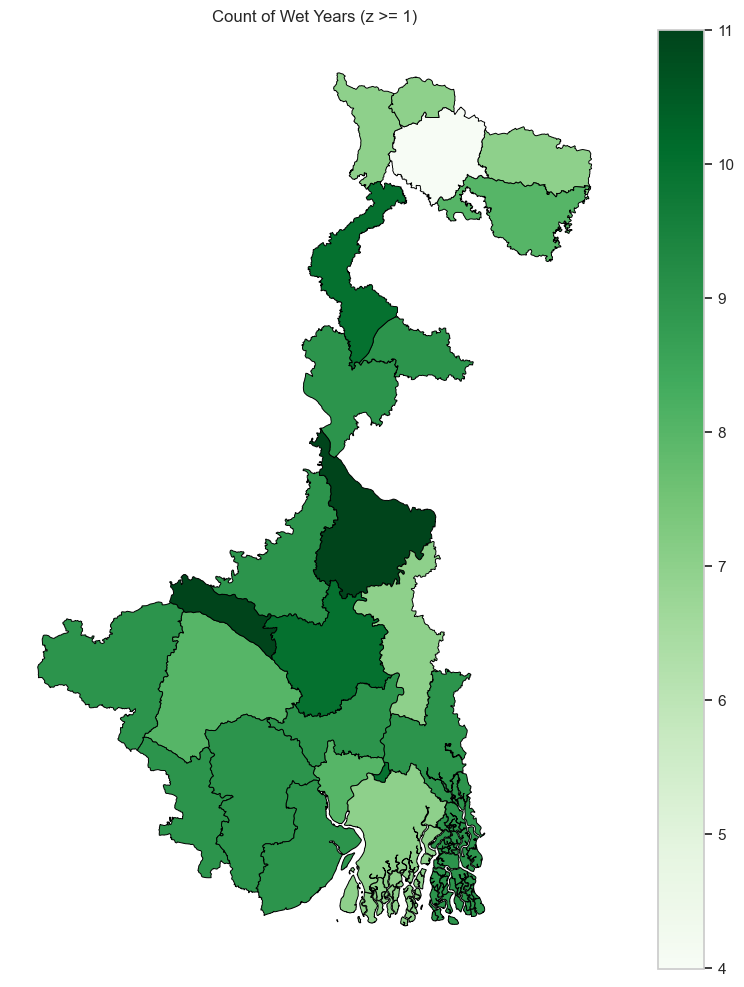

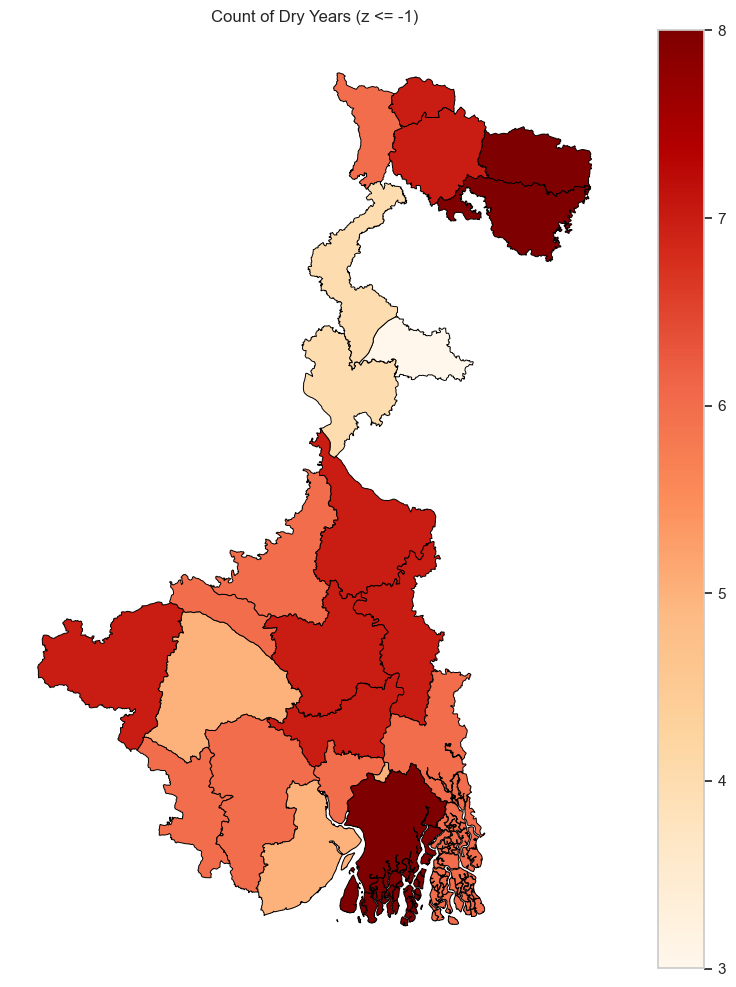

In [28]:

# Wet years map
fig, ax = plt.subplots(figsize=(8, 10))
map_extreme.plot(
    column="wet_years",
    cmap="Greens",
    linewidth=0.7,
    edgecolor="black",
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey", "label": "Missing"}
)
ax.set_title("Count of Wet Years (z >= 1)")
ax.axis("off")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "12_map_wet_years.png", dpi=300, bbox_inches="tight")
plt.show()

# Dry years map
fig, ax = plt.subplots(figsize=(8, 10))
map_extreme.plot(
    column="dry_years",
    cmap="OrRd",
    linewidth=0.7,
    edgecolor="black",
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey", "label": "Missing"}
)
ax.set_title("Count of Dry Years (z <= -1)")
ax.axis("off")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "13_map_dry_years.png", dpi=300, bbox_inches="tight")
plt.show()


## 7) Latent variable support plots

These are optional but useful because they help explain rainfall rather than only describe it. Keep them in the notebook as a compact supporting section.

In [29]:

# Create monthly district averages for latent variables
latent_cols = [c for c in [
    "temperature_2m_c",
    "dewpoint_temperature_2m_c",
    "surface_pressure_hpa",
    "wind_speed_10m"
] if c in monthly_district.columns]

latent_monthly = (
    monthly_district.groupby(["district", "date_month"], as_index=False)[["precip_mm"] + latent_cols]
    .mean()
)

# Correlation summary table
corr_latent = latent_monthly[["precip_mm"] + latent_cols].corr()
corr_latent


,precip_mm,temperature_2m_c,dewpoint_temperature_2m_c,surface_pressure_hpa,wind_speed_10m
precip_mm,1.000000,0.281934,0.570300,-0.321400,-0.010844
temperature_2m_c,0.281934,1.000000,0.831213,0.347869,0.628124
dewpoint_temperature_2m_c,0.570300,0.831213,1.000000,0.137710,0.498314
surface_pressure_hpa,-0.321400,0.347869,0.137710,1.000000,0.534936
wind_speed_10m,-0.010844,0.628124,0.498314,0.534936,1.000000


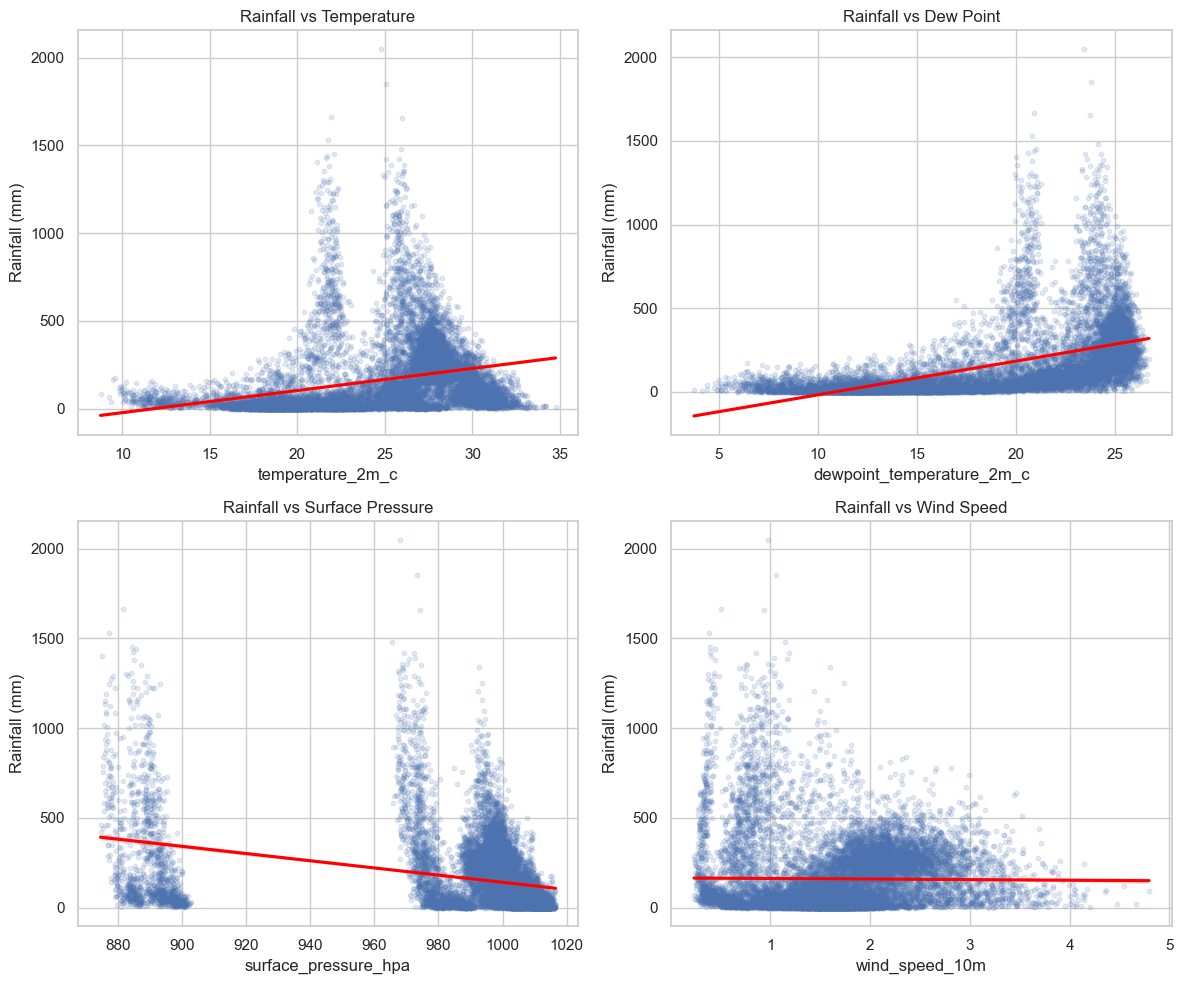

In [30]:

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

pairs = [
    ("temperature_2m_c", "Rainfall vs Temperature"),
    ("dewpoint_temperature_2m_c", "Rainfall vs Dew Point"),
    ("surface_pressure_hpa", "Rainfall vs Surface Pressure"),
    ("wind_speed_10m", "Rainfall vs Wind Speed"),
]

for ax, (col, title) in zip(axes, pairs):
    if col in latent_monthly.columns:
        sns.regplot(
            data=latent_monthly,
            x=col,
            y="precip_mm",
            scatter_kws={"alpha": 0.15, "s": 10},
            line_kws={"color": "red"},
            ax=ax
        )
        ax.set_title(title)
        ax.set_xlabel(col)
        ax.set_ylabel("Rainfall (mm)")

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "14_latent_variable_scatter_grid.png", dpi=300, bbox_inches="tight")
plt.show()


## 8) Save summary tables for later dissertation writing

These tables are useful when writing the EDA section because they turn the plots into compact observations.

In [31]:

station_counts.to_csv(OUTPUT_DIR / "station_counts_by_district.csv", index=False)
monthly_clim.to_csv(OUTPUT_DIR / "monthly_climatology_all_districts.csv", index=False)
district_month_clim.to_csv(OUTPUT_DIR / "district_month_climatology.csv", index=False)
district_annual.to_csv(OUTPUT_DIR / "district_annual_rainfall.csv", index=False)
trend_df.to_csv(OUTPUT_DIR / "trend_slope_by_district.csv", index=False)
monsoon_share_summary.to_csv(OUTPUT_DIR / "monsoon_share_by_district.csv", index=False)
extreme_counts.to_csv(OUTPUT_DIR / "wet_dry_year_counts_by_district.csv", index=False)
corr_monthly.to_csv(OUTPUT_DIR / "district_monthly_correlation_matrix.csv")
corr_latent.to_csv(OUTPUT_DIR / "latent_variable_correlation_matrix.csv")


### End of notebook

The notebook is intentionally compact and reusable: clean inputs from Notebook 00, compute a small set of interpretable summaries, and generate the figures needed for the dissertation. The same structure can be reused for another region by changing the data paths and the shapefile.